# Demo: FOPT Parameters ($T_n$, $\alpha$, $\beta/H$)

This notebook demonstrates how to extract the macroscopic FOPT observables using `FOPTUtilities`.

**Pipeline step:** Fourth layer — takes $S_E(T, g_D)$ (from bounce solvers) and outputs the three numbers that characterize a FOPT:
- $T_n$: nucleation temperature (when one bubble per Hubble volume nucleates)
- $\alpha$: latent heat relative to radiation
- $\beta/H$: inverse duration of the transition

These three numbers are the input to the gravitational wave spectrum calculation.

**Module used:** `src/RGE/FOPT_RGE.py`

**Contents:**
1. Nucleation temperature for a single $g_D$
2. FOPT parameters $\alpha$ and $\beta/H$ at that $g_D$
3. Scan over $g_D \in [0.5, 1.0]$: curves $\alpha(g_D)$ and $\beta/H(g_D)$
4. Save output to `data/final_data/`

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [2]:
# Instantiate the effective potential and the FOPT utilities
veff_obj = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
fopt_obj = fopt.FOPTUtilities(veff_obj=veff_obj)

# Shared parameters for all calculations below
scale = np.pi     # renormalization scale (mu = pi, in natural units)
ls0   = 1e-10     # initial scalar quartic coupling

/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/.venv/lib/python3.9/site-packages/scipy/ndimage/_filters.py:1856: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


## 1. Nucleation temperature $T_n$

`nucTemp` finds the root of the tunneling condition
$$\frac{S_E(T_n)}{T_n} = 4\ln T_n + \frac{3}{2}\ln\frac{S_E/(2\pi T_n)}{T_n^2} - 4\ln H(T_n)$$
using the high-$T$ approximation (`is_HT=True`). The full potential is used when `is_HT=False`.

In [3]:
gD_single = 0.8

Tn = fopt_obj.nucTemp(gD=gD_single, is_HT=True, scale=scale, ls0=ls0)
print(f"gD = {gD_single}")
print(f"Nucleation temperature  Tn = {Tn:.6f}")

gD = 0.8
Nucleation temperature  Tn = 0.111359


## 2. FOPT parameters at a single $g_D$

- **$\alpha(T_n)$**: ratio of latent heat to radiation energy density
- **$\beta/H(T_n)$**: dimensionless inverse duration, $\beta/H = T_n (d\ln S_E/dT)|_{T_n}$

In [4]:
alpha_single = fopt_obj.alpha(Tn, gD_single, is_HT=True, scale=scale)
beta_single  = fopt_obj.beta(Tn, gD_single)

print(f"Nucleation temperature  Tn    = {Tn:.6f}")
print(f"Supercooling parameter  alpha = {alpha_single:.4e}")
print(f"Inverse duration        beta  = {beta_single:.4f}")

Nucleation temperature  Tn    = 0.111359
Supercooling parameter  alpha = 7.0732e+00
Inverse duration        beta  = 127.6268


## 3. Scan over $g_D$

Loop over a grid of $g_D$ values to produce the curves $T_n(g_D)$, $\alpha(g_D)$, $\beta/H(g_D)$ that are the main output of this pipeline.

> **Note:** Each `nucTemp` call invokes the bounce solver internally and may take ~1 min. Reduce `n_gD` for a quick test.

In [5]:
n_gD    = 35
gD_vals = np.linspace(0.5, 1.0, n_gD)

# --- Nucleation temperatures ---
Tn_vals = []
for gD in tqdm(gD_vals, desc="Computing Tn"):
    try:
        Tn_i = fopt_obj.nucTemp(gD=gD, is_HT=True, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals.append(Tn_i)
Tn_vals = np.array(Tn_vals)

# --- Alpha and beta ---
alpha_vals = []
beta_vals  = []
for gD, Tn_i in zip(gD_vals, Tn_vals):
    if np.isfinite(Tn_i):
        try:
            alpha_vals.append(fopt_obj.alpha(Tn_i, gD, is_HT=True, scale=scale))
            beta_vals.append(fopt_obj.beta(Tn_i, gD))
        except Exception:
            alpha_vals.append(np.nan)
            beta_vals.append(np.nan)
    else:
        alpha_vals.append(np.nan)
        beta_vals.append(np.nan)

alpha_vals = np.array(alpha_vals)
beta_vals  = np.array(beta_vals)

Computing Tn: 100%|██████████| 35/35 [00:35<00:00,  1.00s/it]


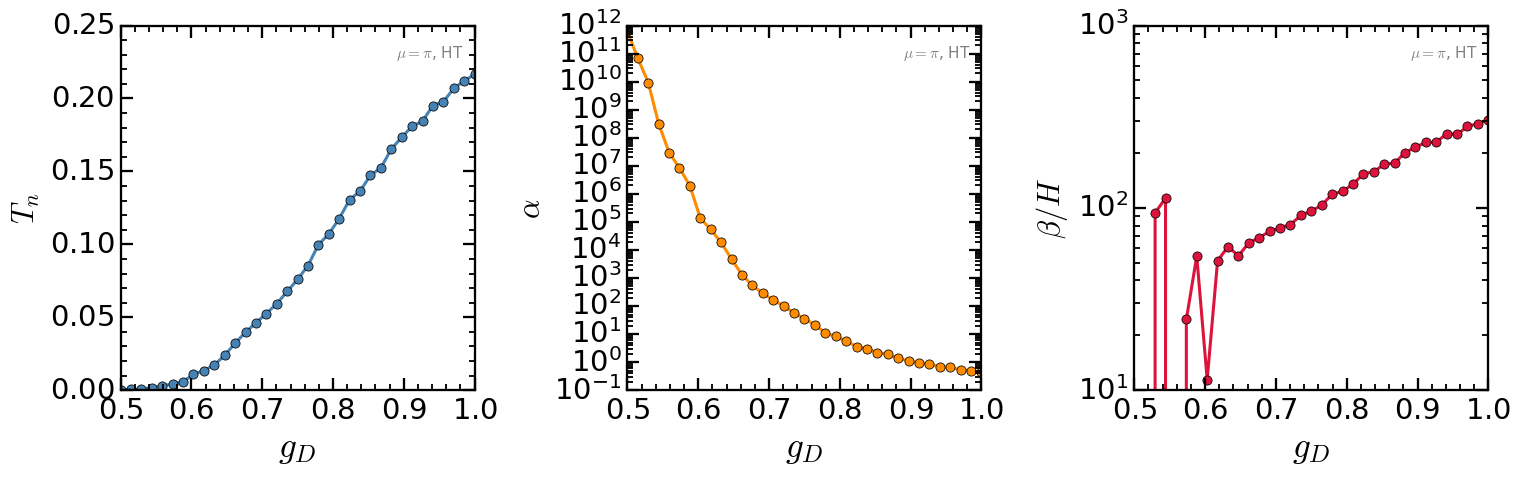

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=110)
fig.patch.set_facecolor('white')

# Tn vs gD
axes[0].plot(gD_vals, Tn_vals, 'o-', lw=2, color='steelblue')
ps.apply_standard_formatting(axes[0], xlabel=r'$g_D$', ylabel=r'$T_n$')

# alpha vs gD
axes[1].plot(gD_vals[np.isfinite(alpha_vals)], alpha_vals[np.isfinite(alpha_vals)],
             'o-', lw=2, color='darkorange')
ps.apply_standard_formatting(axes[1], ylog=True, xlabel=r'$g_D$', ylabel=r'$\alpha$')

# beta vs gD
axes[2].plot(gD_vals[np.isfinite(beta_vals)], beta_vals[np.isfinite(beta_vals)],
             'o-', lw=2, color='crimson')
ps.apply_standard_formatting(axes[2], ylog=True, xlabel=r'$g_D$', ylabel=r'$\beta/H$')

for ax_i in axes:
    ax_i.text(0.97, 0.95, fr'$\mu = \pi$, HT', transform=ax_i.transAxes,
              ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()

## 4. Save output data

The full $(g_D, T_n, \alpha, \beta/H)$ table is the final output of this pipeline stage and the direct input to `demo_GW_spectrum.ipynb`.

In [ ]:
import os
os.makedirs("../data/final_data", exist_ok=True)

data_all = np.column_stack([gD_vals, Tn_vals, alpha_vals, beta_vals])

np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat",
    data_all,
    header="gD    Tn    alpha    beta",
    fmt="%.6e"
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat")
print(f"  {n_gD} rows, gD in [{gD_vals[0]:.2f}, {gD_vals[-1]:.2f}]")